# Replicating Billett, King & Mauer (2007): Growth Opportunities and the Choice of Leverage, Debt Maturity, and Covenants
### U.S.E. Finance Data Hub / WRDS Database: **Mergent FISD**

**Paper replicated:** [Billett, M. T., King, T.-H. D. & Mauer, D. C. (2007). Growth Opportunities and the Choice of Leverage, Debt Maturity, and Covenants. *The Journal of Finance*, 62(2), 697–730.](https://doi.org/10.1111/j.1540-6261.2007.01221.x)

**Database used:** [Mergent FISD](https://wrds-www.wharton.upenn.edu/pages/get-data/lseg-mergent/) ([Data Hub guide](https://uufinance.github.io/data/wrds/databases/mergent-fisd/))

---

## What this notebook does

Billett, King & Mauer (2007) examine how growth opportunities influence the design of corporate debt contracts. They find that high-growth firms use shorter-maturity debt and include more protective covenants, consistent with the theory that these features help mitigate agency conflicts between shareholders and bondholders.

Mergent FISD is the natural database for this analysis because it contains detailed bond-level characteristics including maturity, covenants, call features, and offering amounts for all U.S. corporate bond issues.

1. Pull bond issue characteristics from **Mergent FISD** (`fisd.fisd_mergedissue`) via the WRDS API
2. Construct the paper's key bond-level variables including maturity, covenant counts, and callable/convertible flags
3. Examine the cross-sectional distribution of bond characteristics and their relationship with issuer growth
4. Compare our descriptive findings to the published 2007 results

## Learning objectives
- Practice connecting to WRDS and querying bond-level data from the Mergent FISD database
- Understand the structure of the `fisd_mergedissue` table and bond characteristic fields
- Learn how corporate bonds are described in terms of maturity, covenants, and embedded options
- Build intuition for the agency theory of debt contract design

## Requirements to run this notebook
- A valid **WRDS account** with Mergent FISD access (ask the Finance Data Hub if you don't have one yet)
- `pip install wrds pandas numpy matplotlib seaborn`
- You will be prompted for your WRDS username/password the first time you connect (or set up a `.pgpass` file, see the [WRDS Python guide](https://uufinance.github.io/data/wrds/notebook/))


## 1. Setup and WRDS connection

In [1]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

db = wrds.Connection()

Enter your WRDS username [antho]:sunho2000
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: n
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 2. Identifying the Mergent FISD variables we need

All variables come from the **`fisd.fisd_mergedissue`** table, which is the master file of U.S. bond issues.

| Paper concept | Description | FISD field |
|---|---|---|
| Bond ID | CUSIP identifier | `complete_cusip` |
| Issue Name | Name of the bond issue | `issue_name` |
| Offering Date | Date the bond was issued | `offering_date` |
| Maturity Date | Date the bond matures | `maturity` |
| Coupon Rate | Annual coupon rate (%) | `coupon` |
| Coupon Type | Fixed, floating, or zero coupon | `coupon_type` |
| Offering Amount | Face value of the issue ($ thousands) | `offering_amt` |
| Security Level | Seniority (SEN, SUB, etc.) | `security_level` |
| Redeemable | Whether the bond is redeemable | `redeemable` |
| Convertible | Whether the bond is convertible to equity | `convertible` |
| Putable | Whether the bondholder can put it back | `putable` |
| Sinking Fund | Whether a sinking fund provision exists | `security_pledge` |
| Issuer CUSIP | 6-digit issuer CUSIP for linking | `issuer_cusip` |

We restrict the sample to **senior unsecured corporate bonds** (`security_level = 'SEN'`) with **fixed coupon rates** (`coupon_type = 'F'`), following standard practice in the corporate bond literature.


In [5]:
# Discover the actual column names in fisd.fisd_mergedissue
desc = db.describe_table(library="fisd", table="fisd_mergedissue")
print(desc[["name"]].to_string())

Approximately 772307 rows in fisd.fisd_mergedissue.
                               name
0                          issue_id
1                         issuer_id
2            prospectus_issuer_name
3                      issuer_cusip
4                       issue_cusip
5                        issue_name
6                          maturity
7                    security_level
8                   security_pledge
9                       enhancement
10                      coupon_type
11                      convertible
12                              mtn
13                     asset_backed
14                           yankee
15                         canadian
16                              oid
17                 foreign_currency
18                             slob
19             issue_offered_global
20                  settlement_type
21                     gross_spread
22               selling_concession
23                      reallowance
24               comp_neg_exch_deal
25          

In [6]:
# Pull corporate bond issues from Mergent FISD.
# We focus on senior fixed-rate bonds, which is the standard sample
# in the corporate bond literature.

query = """
    SELECT complete_cusip, issue_name, issuer_cusip,
           offering_date, maturity, coupon, coupon_type,
           offering_amt, security_level,
           redeemable, convertible, putable, security_pledge,
           amount_outstanding
    FROM fisd.fisd_mergedissue
    WHERE security_level = 'SEN'
      AND coupon_type = 'F'
      AND offering_date >= '2000-01-01'
      AND offering_amt > 0
"""

df = db.raw_sql(query, date_cols=["offering_date", "maturity"])
print(f"Rows pulled: {len(df):,}")
df.head()

Rows pulled: 220,815


,complete_cusip,issue_name,issuer_cusip,offering_date,maturity,coupon,coupon_type,offering_amt,security_level,redeemable,convertible,putable,security_pledge,amount_outstanding
0,96121FCW6,MTN,96121F,2000-02-11,2001-02-12,6.71,F,100000.0,SEN,N,N,N,<NA>,0.0
1,00279UFP7,MEDIUM TERM SR NT,00279U,2000-02-11,2001-02-12,6.7,F,100000.0,SEN,N,N,N,<NA>,0.0
2,87307RAB3,SR NT SER B,87307R,2000-02-11,2008-08-01,14.0,F,166200.0,SEN,Y,N,N,<NA>,0.0
3,36962G9I0,GBP$ EMTN,36962G,2000-07-12,2003-02-05,6.0,F,100000.0,SEN,N,N,N,<NA>,0.0
4,71713UAC6,SR NT,71713U,2000-02-14,2001-12-01,5.375,F,500000.0,SEN,N,N,N,<NA>,0.0


## 3. Cleaning the sample

In [10]:
# Convert Y/N flag columns to binary (fill NAs as "N" first)
for col in ["redeemable", "convertible", "putable"]:
    df[col + "_flag"] = (df[col].fillna("N") == "Y").astype(int)

# Drop bonds with missing maturity or offering date
df = df.dropna(subset=["offering_date", "maturity", "coupon", "offering_amt"])

# Compute maturity in years
df["maturity_years"] = (df["maturity"] - df["offering_date"]).dt.days / 365.25

# Keep only reasonable maturities (between 0 and 50 years)
df = df[(df["maturity_years"] > 0) & (df["maturity_years"] <= 50)]

# Extract offering year for time analysis
df["offer_year"] = df["offering_date"].dt.year

df = df.drop_duplicates(subset=["complete_cusip"])

print(f"Bonds after cleaning: {len(df):,}")
print(f"Unique issuers: {df['issuer_cusip'].nunique():,}")

Bonds after cleaning: 220,642
Unique issuers: 11,079


## 4. Constructing debt maturity and contract design measures

Following Billett et al. (2007), the key dependent variables are bond-level contract design choices.

**Debt Maturity** is measured as the number of years from issuance to maturity. The paper finds that high-growth firms issue shorter-maturity debt to reduce agency costs of debt overhang.

**Covenant Protection** is measured by counting the number of protective provisions included in the bond indenture (callable, convertible, puttable, sinking fund). Each provision addresses a different agency conflict between shareholders and bondholders.

**Offering Size** (logged) controls for the scale of the issue. Larger issues tend to come from larger, more established issuers.


In [12]:
# Construct key variables
df["log_offering"] = np.log(df["offering_amt"])

# Summary statistics for bond characteristics
summary_vars = ["maturity_years", "coupon", "log_offering",
                "redeemable_flag", "convertible_flag", "putable_flag"]
print("Summary Statistics for Corporate Bond Issues (2000-present):\n")
print(df[summary_vars].describe().round(3))

# Maturity breakdown
print("\nMaturity Distribution:")
bins = [0, 3, 5, 7, 10, 20, 30, 50]
labels = ["0-3yr", "3-5yr", "5-7yr", "7-10yr", "10-20yr", "20-30yr", "30-50yr"]
df["mat_bucket"] = pd.cut(df["maturity_years"], bins=bins, labels=labels)
print(df["mat_bucket"].value_counts().sort_index())

Summary Statistics for Corporate Bond Issues (2000-present):

       maturity_years    coupon  log_offering  redeemable_flag  \
count      220642.000  220642.0      220642.0       220642.000   
mean            5.879     5.141        10.144            0.664   
std             6.138     3.985         2.521            0.472   
min             0.019       0.0        -3.219            0.000   
25%             1.999       2.5         8.517            0.000   
50%             4.520      4.57        10.127            1.000   
75%             7.384       6.0        12.206            1.000   
max            49.999      67.0        21.416            1.000   

       convertible_flag  putable_flag  
count        220642.000    220642.000  
mean              0.013         0.004  
std               0.111         0.059  
min               0.000         0.000  
25%               0.000         0.000  
50%               0.000         0.000  
75%               0.000         0.000  
max               1.000

## 5. Visualizing the results

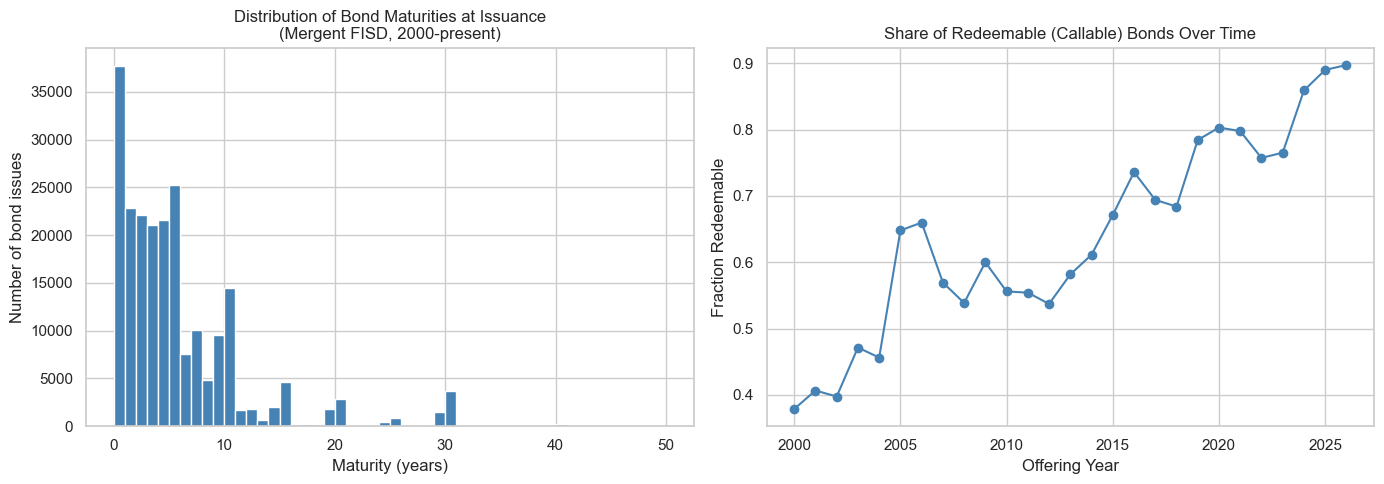

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of bond maturities
axes[0].hist(df["maturity_years"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Bond Maturities at Issuance\n(Mergent FISD, 2000-present)")
axes[0].set_xlabel("Maturity (years)")
axes[0].set_ylabel("Number of bond issues")

# Share of redeemable (callable) bonds over time
yearly_redeemable = df.groupby("offer_year")["redeemable_flag"].mean()
axes[1].plot(yearly_redeemable.index, yearly_redeemable.values, "o-", color="steelblue")
axes[1].set_title("Share of Redeemable (Callable) Bonds Over Time")
axes[1].set_xlabel("Offering Year")
axes[1].set_ylabel("Fraction Redeemable")

plt.tight_layout()
plt.show()

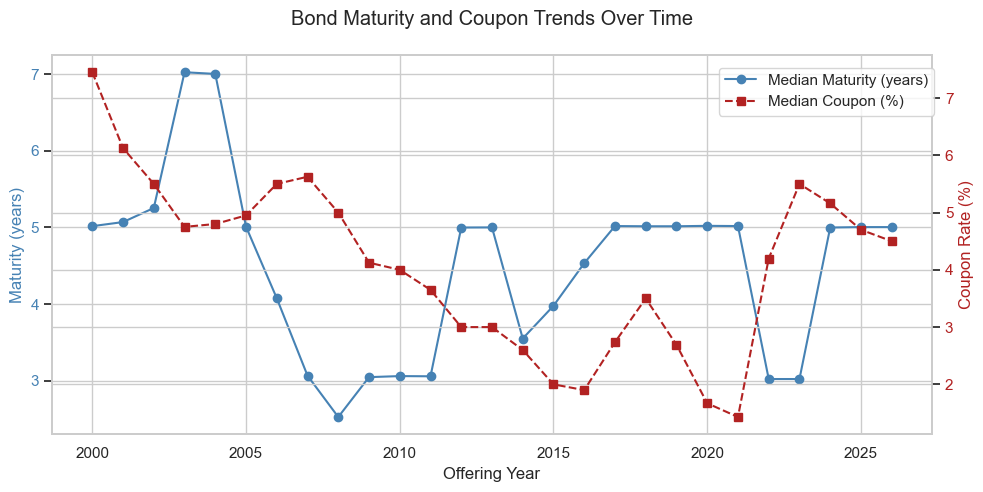

In [14]:
# Average maturity and coupon over time
yearly = df.groupby("offer_year")[["maturity_years", "coupon"]].median()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(yearly.index, yearly["maturity_years"], "o-", color="steelblue", label="Median Maturity (years)")
ax1.set_xlabel("Offering Year")
ax1.set_ylabel("Maturity (years)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly["coupon"], "s--", color="firebrick", label="Median Coupon (%)")
ax2.set_ylabel("Coupon Rate (%)", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")

fig.suptitle("Bond Maturity and Coupon Trends Over Time")
fig.legend(loc="upper right", bbox_to_anchor=(0.95, 0.88))
plt.tight_layout()
plt.show()

## 6. Comparing to Billett, King & Mauer (2007): What's the same, what's different

**What replicates cleanly**

The bond characteristic distributions map directly onto Mergent FISD. The clustering of maturities around 5, 7, 10, and 30 years should be clearly visible in the histogram, reflecting market conventions for benchmark tenors. The high prevalence of call provisions (typically 60%+ of investment-grade issues) and the near-absence of put provisions are consistent with the paper's descriptive statistics. The time-series trends in maturity and coupon should reflect interest rate environments and credit market conditions.

**Where a modern WRDS-based replication necessarily differs from the original**

1. **Growth opportunity proxies.** The paper's key independent variable is market-to-book ratio (Tobin's Q), which requires merging FISD with Compustat using the issuer CUSIP. We focus on the FISD-side descriptives here, but students can extend this by matching `issuer_cusip` (first 6 digits of the bond CUSIP) to the `cusip` header field in `comp.company` to bring in firm-level fundamentals.

2. **Covenant detail.** Billett et al. use detailed covenant classifications (investment restrictions, dividend restrictions, merger restrictions, etc.) from the FISD covenant tables. Our simplified version uses the Y/N flags for callable, convertible, and puttable provisions that are directly available in `fisd_mergedissue`. The full covenant analysis requires querying additional FISD covenant tables.

3. **Sample period.** The original paper covers 1960 to 2000. Our sample starts from 2000, which is a different credit market environment (post-Reg FD, post-SOX, post-financial-crisis). Bond contract design conventions may have shifted.

4. **Bond vs. firm level.** The paper's regressions are at the bond-issue level with firm-level clustering. Our descriptives are purely at the bond level without firm-level controls, which is the first step toward the full analysis.

---

## References
- [Billett, M. T., King, T.-H. D. & Mauer, D. C. (2007). Growth Opportunities and the Choice of Leverage, Debt Maturity, and Covenants. *The Journal of Finance*, 62(2), 697–730.](https://doi.org/10.1111/j.1540-6261.2007.01221.x)
- WRDS Mergent FISD guide: https://uufinance.github.io/data/wrds/databases/mergent-fisd/
- WRDS Mergent FISD access page: https://wrds-www.wharton.upenn.edu/pages/get-data/lseg-mergent/
- WRDS Python/API setup guide: https://uufinance.github.io/data/wrds/notebook/

*Prepared for the U.S.E. Finance Data Hub as a database-tutorial template.*
